In [ ]:
import gdown
import os
import shutil

url = 'https://drive.google.com/drive/folders/1Y8ZsnM8d-MNrYeoT781w8U7u4e6wPIwp'

folder = 'dataset'
gdown.download_folder(url, output=folder, quiet=True)

['dataset/1 Pecah_retak.png',
 'dataset/2 Pecah_retak.png',
 'dataset/3 Pecah_retak.png',
 'dataset/4 Pecah_retak.png',
 'dataset/5 Pecah_retak.png',
 'dataset/6 berlubang.png',
 'dataset/8 berlubang.png',
 'dataset/11 lain lain.png',
 'dataset/12 lain lain.png',
 'dataset/15 lain lain.png']

Processing: dataset/1 Pecah_retak.png


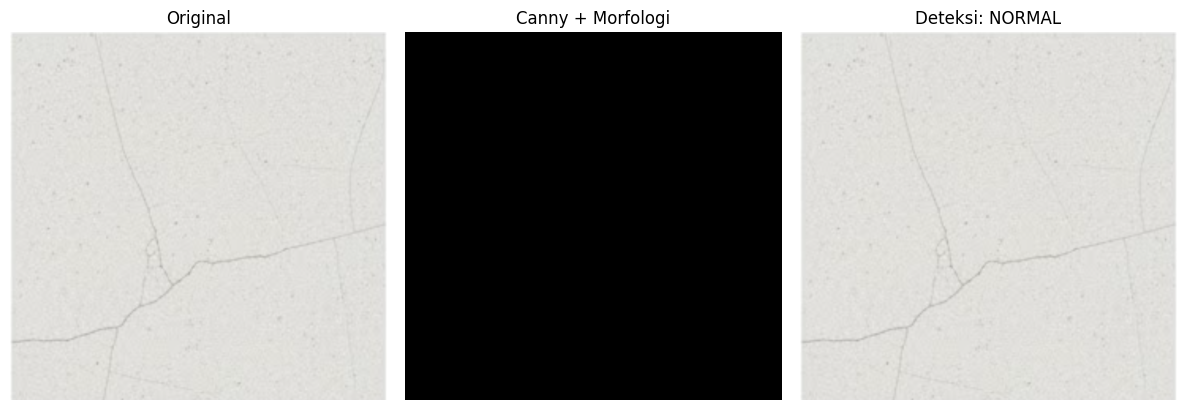

Processing: dataset/11 lain lain.png


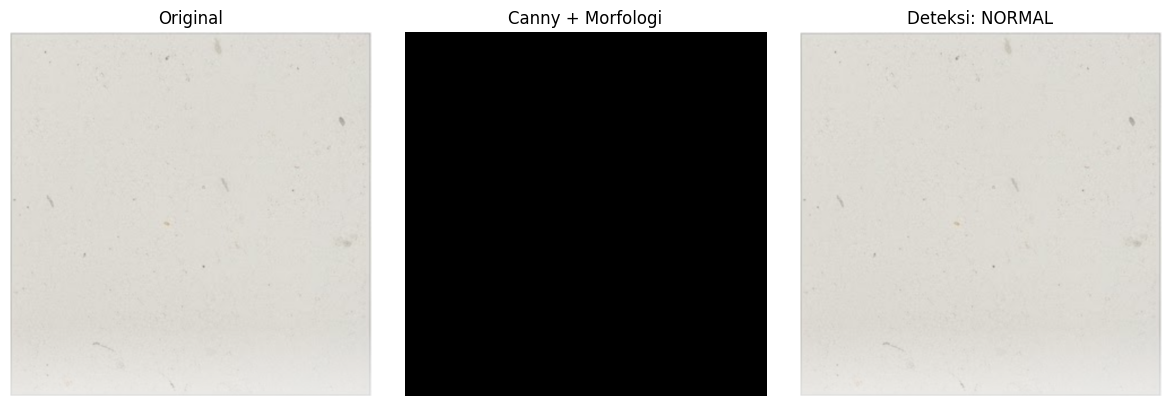

Processing: dataset/12 lain lain.png


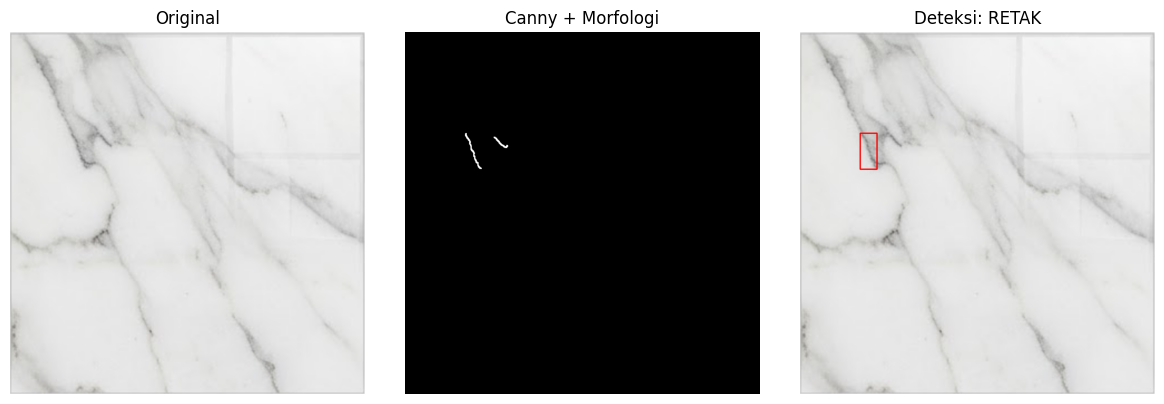

Processing: dataset/15 lain lain.png


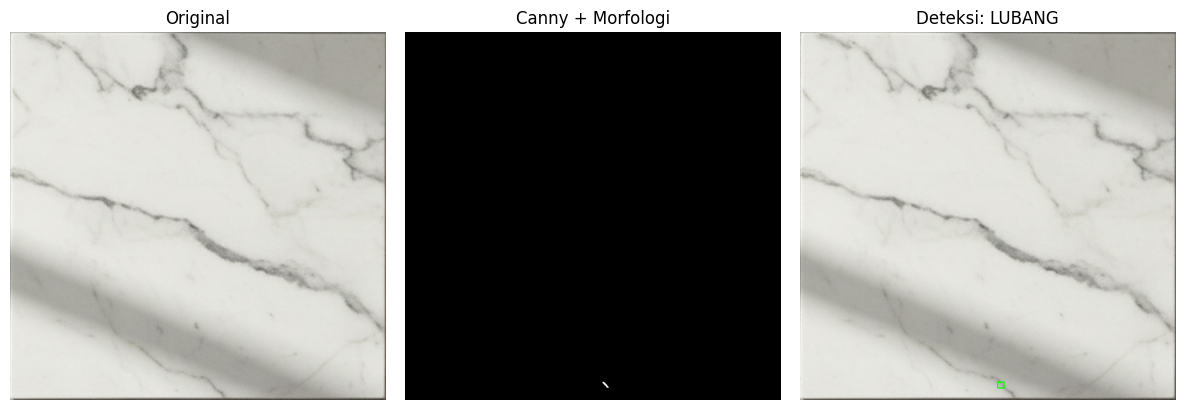

Processing: dataset/2 Pecah_retak.png


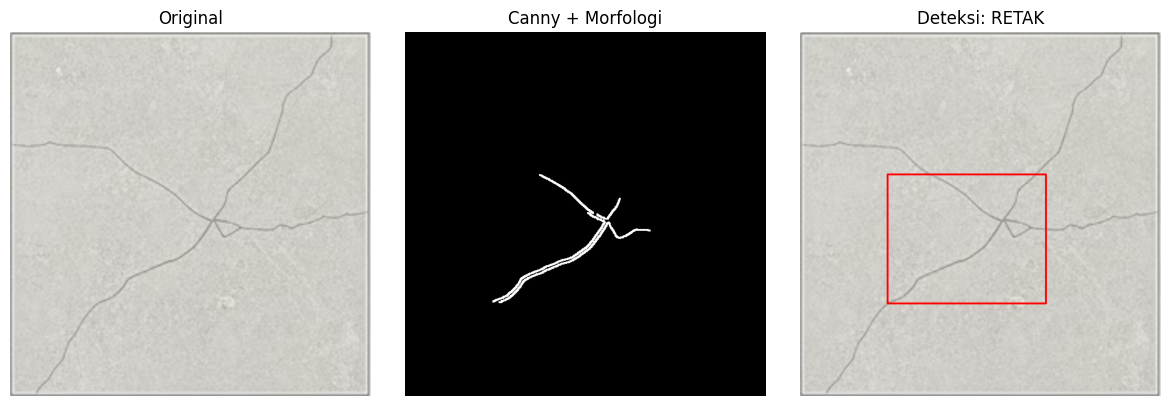

Processing: dataset/3 Pecah_retak.png


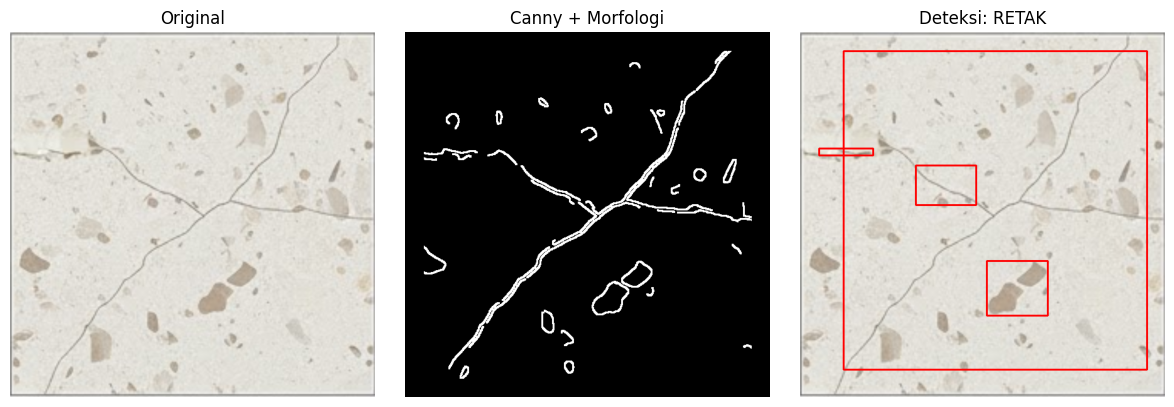

Processing: dataset/4 Pecah_retak.png


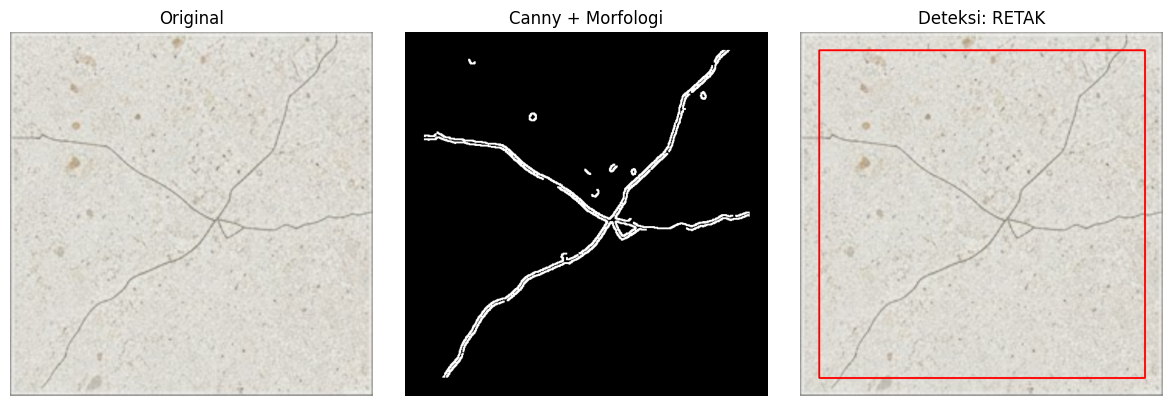

Processing: dataset/5 Pecah_retak.png


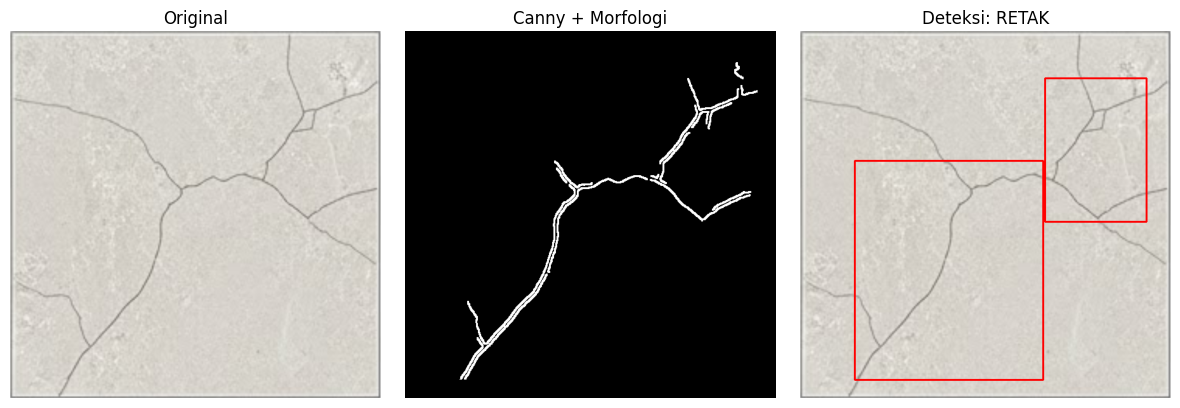

Processing: dataset/6 berlubang.png


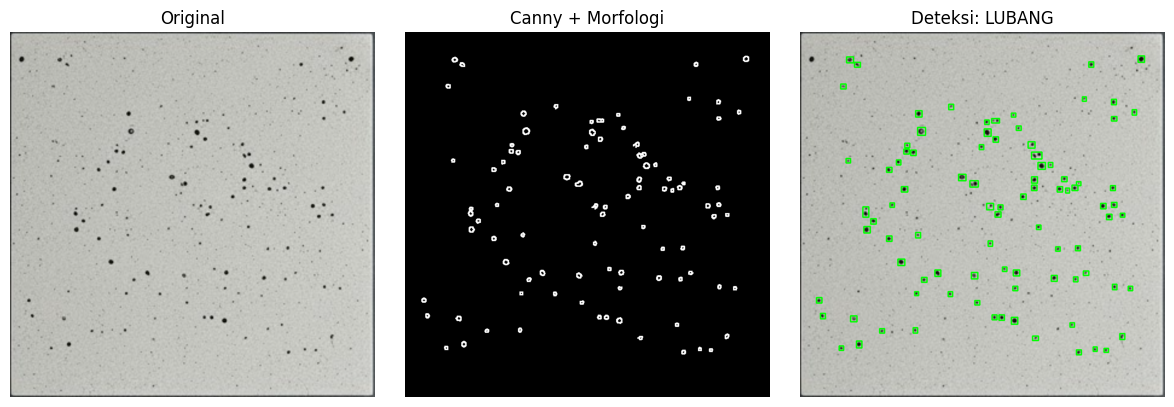

Processing: dataset/8 berlubang.png


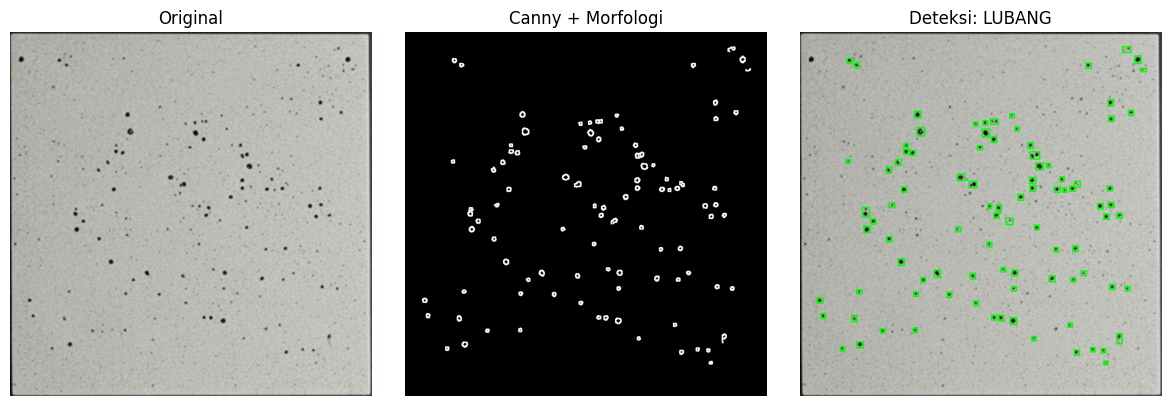

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Tuple, List, Optional

class CeramicDefectDetector:
    """
    Sistem deteksi cacat (retak dan lubang) pada permukaan keramik
    menggunakan segmentasi morfologi dan deteksi tepi.
    """

    def __init__(self, margin: int = 30, min_area: int = 50):
        self.margin = margin
        self.min_area = min_area

    def remove_frame(self, mask: np.ndarray) -> np.ndarray:
        h, w = mask.shape
        clean_mask = np.zeros_like(mask)
        cv2.rectangle(clean_mask, (self.margin, self.margin), (w - self.margin, h - self.margin), 255, -1)
        return cv2.bitwise_and(mask, mask, mask=clean_mask)

    def auto_canny(self, image: np.ndarray, sigma: float = 0.33) -> np.ndarray:
        v = np.median(image)
        lower = int(max(0, (1.0 - sigma) * v))
        upper = int(min(255, (1.0 + sigma) * v))
        return cv2.Canny(image, lower, upper)

    def analyze_image(self, file_path: Path) -> None:
        image_bgr = cv2.imread(str(file_path))
        if image_bgr is None:
            print(f"Error: Tidak dapat membaca file {file_path.name}")
            return

        image_result = image_bgr.copy()
        image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        contrast_img = clahe.apply(image_gray)
        filtered_img = cv2.bilateralFilter(contrast_img, 9, 75, 75)

        edges = self.auto_canny(filtered_img)

        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
        dilated_edges = cv2.dilate(edges, kernel, iterations=1)
        final_mask = cv2.morphologyEx(dilated_edges, cv2.MORPH_OPEN, kernel)

        final_mask = self.remove_frame(final_mask)

        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(final_mask, connectivity=8)
        object_mask = np.zeros_like(final_mask)

        for i in range(1, num_labels):
            if stats[i, cv2.CC_STAT_AREA] > self.min_area:
                object_mask[labels == i] = 255

        contours, _ = cv2.findContours(object_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        cracks = []
        holes = []

        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            diagonal = np.sqrt(w**2 + h**2)
            area = cv2.contourArea(cnt)
            ratio = float(w) / h if h > 0 else 0.0

            is_long = diagonal > 60
            is_flat = (ratio > 3.0 or ratio < 0.33) and diagonal > 30

            if is_long or is_flat:
                cracks.append(cnt)
            elif 10 < diagonal < 60 and area > 10:
                if 0.5 < ratio < 2.0:
                    holes.append(cnt)

        status = "NORMAL"
        color = (0, 0, 0)

        if cracks:
            status = "RETAK"
            color = (0, 0, 255)
            self._draw_bounding_boxes(image_result, cracks, color)
        elif holes:
            status = "LUBANG"
            color = (0, 255, 0)
            self._draw_bounding_boxes(image_result, holes, color)

        self.visualize(image_bgr, object_mask, image_result, status)

    def _draw_bounding_boxes(self, image: np.ndarray, contours: List[np.ndarray], color: Tuple[int, int, int]) -> None:
        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            cv2.rectangle(image, (x, y), (x + w, y + h), color, 2)

    def visualize(self, original: np.ndarray, mask: np.ndarray, result: np.ndarray, status: str) -> None:
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.title("Original")
        plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.title("Canny + Morphology")
        plt.imshow(mask, cmap='gray')
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.title(f"Detection: {status}")
        plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
        plt.axis('off')

        plt.tight_layout()
        plt.show()

def main():
    detector = CeramicDefectDetector()
    dataset_path = Path('dataset')

    if not dataset_path.exists() or not dataset_path.is_dir():
        print(f"Direktori '{dataset_path}' tidak ditemukan.")
        return

    image_files = sorted(dataset_path.glob('*.png'))

    if not image_files:
        print(f"Tidak ada file .png ditemukan di dalam '{dataset_path}'")
        return

    for image_path in image_files:
        print(f"Processing: {image_path.name}")
        detector.analyze_image(image_path)

if __name__ == "__main__":
    main()